# **Step2_AI 강사 Agent v2.0**

## **0. 미션**

### **미션③ : 모듈 고도화1**
다음 항목에 대해서 조 상황에 맞게 선택적으로 고도화 합니다.

* 입력 프롬프트 추가 : 강의 목소리, 톤 조절, 강의 스타일 지침
* 정보 분해 : 여러 슬라이드를 저장하고 관리하기 위한 폴더 준비, 불필요한 정보 제거, 제목 추출
* 페이지별 내용 생성 : 슬라이드 내 정보 뿐만 아니라 부연 설명을 위한 검색 기능 추가
* 강의 스크립트 생성 : 전체 강의 내용을 참조하여 강의 흐름을 구상하고,
                                   현재 페이지 강의 스크립트 작성
* 내용 검토 : 페이지 내용과 강의 스크립트 비교, 강의 스크립트 흐름 적절한지 검토




### **미션④ : AI 강사 Agent 완성**
* 모듈 고도화2(다음 항목에 대해서 조 상황에 맞게 선택적으로 고도화 합니다.)
    * 음성 변환 : 강의 목소리, 톤 조절 음성 변환
    * 영상 제작 :
        * 각 페이지 : 음성과 슬라이드 스냅샷 이미지 합성하여 영상 제작하기
        * 전체 강의 영상 : 각 슬라이드 강의를 전체 슬라이드 강의 영상으로 합치기
* 웹 화면 연결(gradio)
    * 음성 변환 : 강의 목소리, 톤 조절 프롬프트 기반 음성 변환
* 전체 Agent 그래프 구축
    * 전체를 Agent 그래프로 엮기


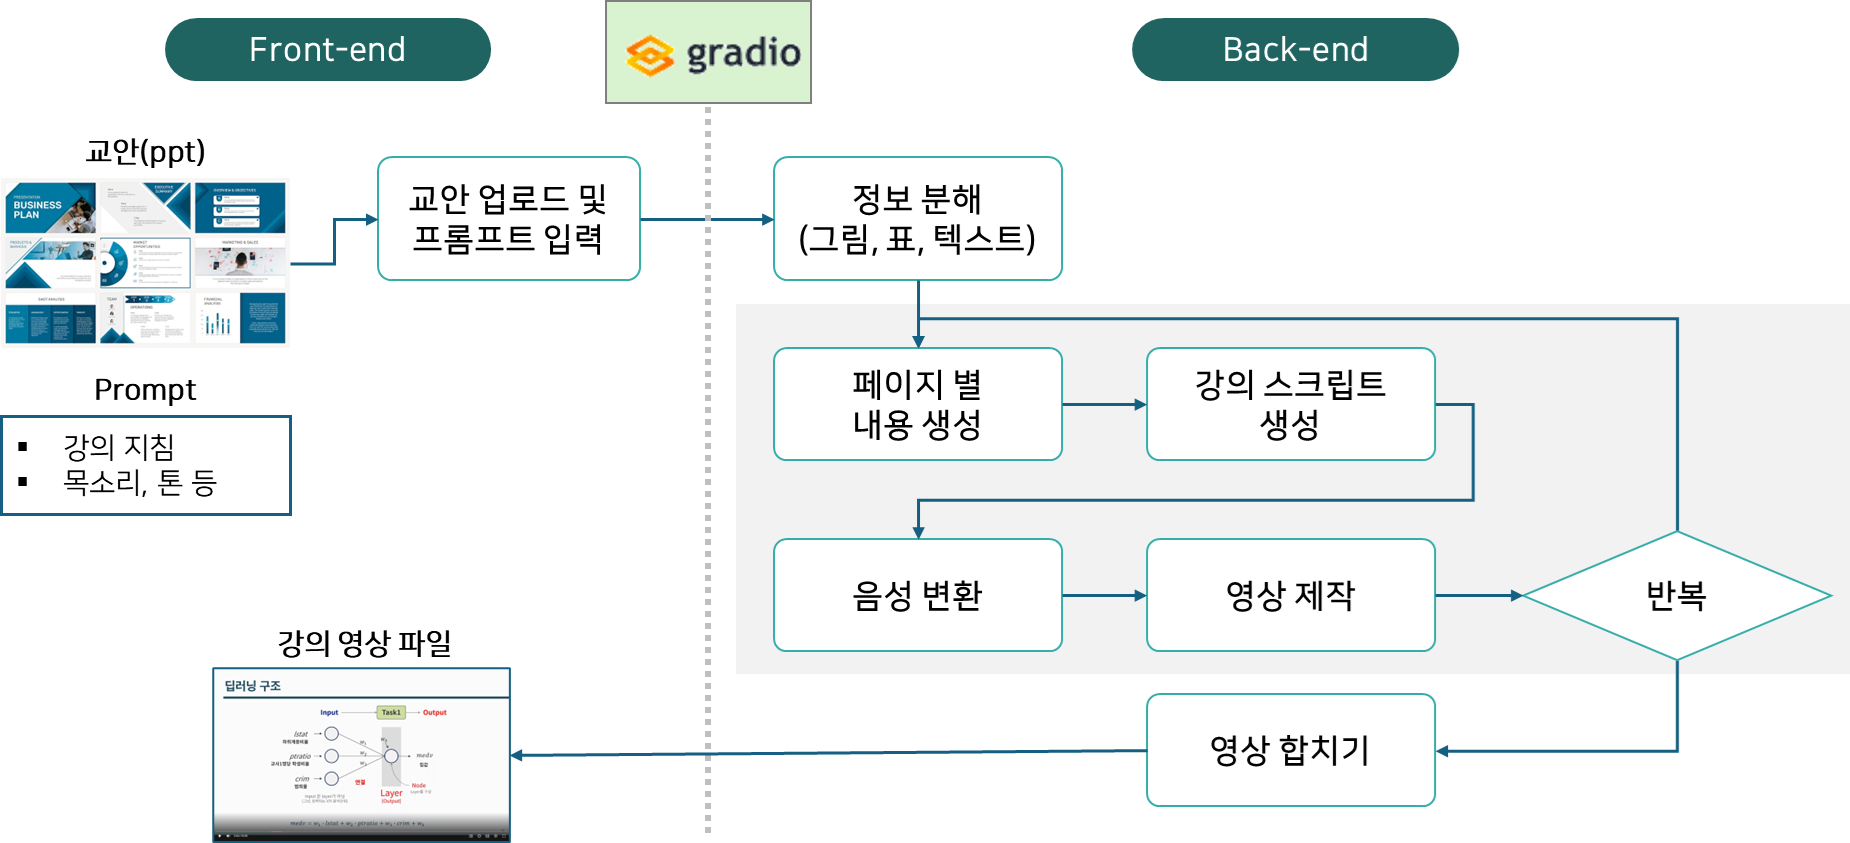

## **1. 환경준비**

### (1) 구글 드라이브

* 구글 드라이브 폴더 생성
    * 새 폴더 `proj1_agent`를 생성하고
    * 제공 받은 파일을 업로드

* 구글 드라이브 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### (2) 한글 폰트 준비
* 한글 폰트 설치 및 설정 코드
* 영상 제작 등 한글 사용시 필요

In [ ]:
%%bash
set -e

# (1) 필수 패키지
sudo apt-get update -y
sudo apt-get install -y \
  libreoffice poppler-utils poppler-data ffmpeg locales fontconfig xvfb \
  fonts-noto-core fonts-noto-cjk fonts-noto-cjk-extra

# (2) 로케일
sudo sed -i 's/^# *ko_KR.UTF-8 UTF-8/ko_KR.UTF-8 UTF-8/' /etc/locale.gen
sudo locale-gen ko_KR.UTF-8
sudo update-locale LANG=ko_KR.UTF-8

# (3) 기존에 만들었던 사용자 fonts.conf(전체 덮어쓰기) 제거
rm -f ~/.config/fontconfig/fonts.conf || true

# (4) 시스템 fontconfig에 로컬 룰로만 추가 (기본 설정은 그대로 사용)
sudo tee /etc/fonts/local.conf >/dev/null <<'EOF'
<?xml version="1.0"?>
<!DOCTYPE fontconfig SYSTEM "fonts.dtd">
<fontconfig>

  <!-- 한국어는 Noto Sans KR 우선 -->
  <match target="pattern">
    <test name="lang" compare="contains"><string>ko</string></test>
    <edit name="family" mode="prepend" binding="strong">
      <string>Noto Sans KR</string>
      <string>Noto Sans CJK KR</string>
      <string>Noto Sans</string>
    </edit>
  </match>

  <!-- 흔한 한글 폰트명을 Noto Sans KR로 매핑 -->
  <alias><family>Malgun Gothic</family><prefer><family>Noto Sans KR</family></prefer></alias>
  <alias><family>맑은 고딕</family><prefer><family>Noto Sans KR</family></prefer></alias>
  <alias><family>Apple SD Gothic Neo</family><prefer><family>Noto Sans KR</family></prefer></alias>
  <alias><family>AppleGothic</family><prefer><family>Noto Sans KR</family></prefer></alias>

</fontconfig>
EOF

# (5) 캐시 완전 재생성
rm -rf ~/.cache/fontconfig
sudo fc-cache -r
fc-cache -f -v >/dev/null

# (6) 검증
echo "---- fc-match ko ----"
fc-match "sans-serif:lang=ko"
echo "---- noto candidates ----"
fc-list | grep -i -E "noto.*(sans|cjk).*kr" | head -n 30 || true

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://cli.github.com/packages stable InRelease [3,917 B]
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:6 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:10 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:11 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,292 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,863 kB]
Get:14

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 150.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 


### (3) 라이브러리

* 필요한 라이브러리 설치

In [ ]:
!pip install langchain-openai langchain-community python-pptx pillow gradio langchain-tavily tavily-python -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.4/542.4 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


In [ ]:
!apt-get install imagemagick
!sed -i 's/<policy domain="path" rights="none" pattern="@\*"/<policy domain="path" rights="read|write" pattern="@\*"/g' /etc/ImageMagick-6/policy.xml

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-droid-fallback fonts-urw-base35 ghostscript gsfonts
  imagemagick-6-common imagemagick-6.q16 libdjvulibre-text libdjvulibre21
  libfftw3-double3 libgs9 libgs9-common libidn12 libijs-0.35 libilmbase25
  libjbig2dec0 libjxr-tools libjxr0 liblqr-1-0 libmagickcore-6.q16-6
  libmagickcore-6.q16-6-extra libmagickwand-6.q16-6 libnetpbm10 libopenexr25
  libwmflite-0.2-7 netpbm
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-freefont-ttf fonts-texgyre
  ghostscript-x imagemagick-doc autotrace cups-bsd | lpr | lprng enscript gimp
  gnuplot grads hp2xx html2ps libwmf-bin mplayer povray radiance sane-utils
  texlive-base-bin transfig ufraw-batch libfftw3-bin libfftw3-dev inkscape
The following NEW packages will be installed:
  fonts-droid-fallback fonts-urw-base35 ghostscript gsfonts imagemagick
  imagemagick-6-common imagemagick-

* 라이브러리 로딩

In [ ]:
import os, re, textwrap, subprocess, json, base64, mimetypes, shlex
from pathlib import Path
from dataclasses import dataclass
from typing import List, Dict, Optional, TypedDict, Any
from PIL import Image, ImageDraw
from pptx import Presentation
from pptx.enum.shapes import MSO_SHAPE_TYPE
from openai import OpenAI
from google.colab import files
from IPython.display import Audio, display, Video

from langchain_tavily import TavilySearch
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

### (4) API Key 확인
* 구글드라이브에 생성한 폴더 `proj1_agent` 에서
* api_key.txt 파일 안에 각자 발급 받은 키를 저장합니다.
    * **OPENAI_API_KEY**
    * **TAVILY_API_KEY**

In [ ]:
def load_api_keys(filepath="api_key.txt"):
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line and "=" in line:
                key, value = line.split("=", 1)
                os.environ[key.strip()] = value.strip()

path = '/content/drive/MyDrive/proj1_agent/'
# API 키 로드 및 환경변수 설정
load_api_keys(path + 'api_key.txt')

⚠️ 아래 코드셀은, 실행해서 key가 제대로 보이는지 확인하고 삭제하세요.

In [ ]:
print(os.environ['OPENAI_API_KEY'][:30])
print(os.environ['TAVILY_API_KEY'][:30])

sk-proj-9kaLYbWragOjTSuzNrle-g
tvly-dev-Yr1S6-lS1htvTWO0Buyx7


### (5) 유용한 함수들 제공
* 다음은 프로젝트를 수행하는데 유용한 함수들입니다.
* 이 함수들의 내용을 확인하고 필요시 활용하여 개인 과제를 수행합니다.(꼭 활용해야 하는 것은 아닙니다.)

* 공백 제거 함수

In [ ]:
def clean_text(s):
    return re.sub(r"\s+", " ", s).strip()

* 긴 문자열을 문장 단위로 나누는 문장 분리기

In [ ]:
def split_sents(t: str) -> List[str]:
    parts = re.split(r'([\.?!])', t)
    merged = []
    for i in range(0, len(parts)-1, 2):
        sent = (parts[i] + parts[i+1]).strip()
        if sent: merged.append(sent)
    if len(parts) % 2 == 1 and parts[-1].strip():
        merged.append(parts[-1].strip())
    return [s for s in merged if s]

* 오디오 길이 계산

In [ ]:
def ffprobe_duration(path: str) -> float:
    out = subprocess.check_output([
        "ffprobe","-v","error","-show_entries","format=duration",
        "-of","default=noprint_wrappers=1:nokey=1", path]).decode().strip()
    return float(out)

* 이미지를 base64로 변환

In [ ]:
def img_to_data_url(path: str) -> str:
    mime = mimetypes.guess_type(path)[0] or "image/png"
    with open(path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode("utf-8")
    return f"data:{mime};base64,{b64}"

* 배경 이미지와 오디오 합쳐서 MP4 영상 만들기

In [ ]:
def render_mp4(image_path: str, audio_path: str, out_mp4: str,
               width=1920, height=1080, ):

    dur = ffprobe_duration(audio_path)

    vf = (f"scale={width}:{height}:force_original_aspect_ratio=decrease,"
          f"pad={width}:{height}:(ow-iw)/2:(oh-ih)/2:color=black"  )

    # FFmpeg 명령
    cmd = ["ffmpeg", "-y",
            "-loop", "1", "-i", image_path,   # 정지 이미지 입력
            "-i", audio_path,                 # 오디오 입력
            "-t", str(dur),                   # 길이 = 오디오 길이
            "-vf", vf,                        # 비디오 필터
            "-c:v", "libx264", "-preset", "veryfast", "-crf", "20",
            "-c:a", "aac", "-b:a", "192k",
            "-pix_fmt", "yuv420p",
            "-movflags", "+faststart",        # 웹/브라우저 재생 친화
            out_mp4]
    subprocess.check_call(cmd)  # 외부 프로그램(FFmpeg)을 파이썬 프로세스에서 실행하고, 성공했는지 확인

* ppt 슬라이드를 배경 이미지로 저장
    * 강의 영상에서 사용할 배경 이미지 생성하기
    * ppt를 pdf로 변환한 뒤 다시 이미지로 변환

In [ ]:
import os, subprocess, uuid
from pathlib import Path

def export_slide_as_png(state: dict, dpi: int = 220) -> dict:
    work_dir = Path(state["work_dir"]).expanduser().resolve()
    work_dir.mkdir(parents=True, exist_ok=True)

    pptx = Path(state["pptx_path"]).expanduser().resolve()
    if not pptx.exists():
        raise FileNotFoundError(f"PPTX 없음: {pptx}")

    idx = int(state.get("slide_index", 0))  # 0-based
    page_no = idx + 1
    out_prefix = work_dir / "slide_img"

    # LibreOffice 프로필(캐시) 꼬임 방지
    lo_profile = f"file:///tmp/lo_profile_{uuid.uuid4().hex}"

    # fontconfig/locale 강제
    env = os.environ.copy()
    env.update({
        "LANG": "ko_KR.UTF-8",
        "LC_ALL": "ko_KR.UTF-8",
        "FONTCONFIG_PATH": str(Path("~/.config/fontconfig").expanduser()),
        "FONTCONFIG_FILE": str(Path("~/.config/fontconfig/fonts.conf").expanduser()),
        "HOME": str(Path("~").expanduser()),
        "XDG_CACHE_HOME": str(Path("~/.cache").expanduser()),
        "SAL_USE_VCLPLUGIN": "gen",
    })

    def run_lo_convert(convert_to: str):
        # X11 요구 해결: xvfb-run로 감싼다 (Colab 필수급)
        cmd = [
            "xvfb-run", "-a",
            "soffice", "--headless", "--nologo", "--nofirststartwizard", "--norestore",
            f"-env:UserInstallation={lo_profile}",
            "--convert-to", convert_to,
            "--outdir", str(work_dir),
            str(pptx),
        ]
        return subprocess.run(cmd, capture_output=True, text=True, env=env)

    # --- A) PPTX → PNG ---
    before_png = set(work_dir.glob("*.png"))
    res_png = run_lo_convert("png:impress_png_Export")

    created_png = [p for p in work_dir.glob("*.png") if p not in before_png]
    candidate = None

    exact = [p for p in created_png if p.stem.endswith(f"-{page_no}")]
    if exact:
        candidate = max(exact, key=lambda p: p.stat().st_mtime)
    elif created_png:
        candidate = max(created_png, key=lambda p: p.stat().st_mtime)

    if candidate and candidate.exists():
        state["slide_image"] = str(candidate)
        return state

    # --- B) 폴백: PPTX → PDF → PNG ---
    before_pdf = set(work_dir.glob("*.pdf"))
    res_pdf = run_lo_convert("pdf:impress_pdf_Export")

    target_pdf = work_dir / f"{pptx.stem}.pdf"
    created_pdf = [p for p in work_dir.glob("*.pdf") if p not in before_pdf]

    if target_pdf.exists():
        pdf_path = target_pdf
    elif created_pdf:
        pdf_path = max(created_pdf, key=lambda p: p.stat().st_mtime)
    else:
        print("LibreOffice PPTX→PDF 변환 실패")
        print("stdout:", res_pdf.stdout)
        print("stderr:", res_pdf.stderr)
        raise RuntimeError("PPTX → PDF 변환 실패")

    ppm_cmd = [
        "pdftoppm",
        "-f", str(page_no), "-l", str(page_no),
        "-png", "-r", str(dpi),
        str(pdf_path),
        str(out_prefix)
    ]
    res2 = subprocess.run(ppm_cmd, capture_output=True, text=True, env=env)

    png_path = Path(f"{out_prefix}-{page_no}.png")
    if not png_path.exists():
        print("pdftoppm 변환 실패")
        print("stdout:", res2.stdout)
        print("stderr:", res2.stderr)
        raise RuntimeError("PDF → PNG 변환 실패")

    state["slide_image"] = str(png_path)
    return state

* 영상 합치기 : 여러 영상 경로를 리스트로 입력 받아 합치기

In [ ]:
def concat_videos_ffmpeg(video_paths: List[str], out_path: str, reencode: bool=False):
    list_path = out_path + ".txt"
    with open(list_path, "w", encoding="utf-8") as f:
        for v in video_paths:
            f.write(f"file '{os.path.abspath(v)}'\n")
    if reencode:
        cmd = [
            "ffmpeg","-y","-safe","0","-f","concat","-i",list_path,
            "-vf","format=yuv420p",
            "-c:v","libx264","-preset","veryfast",
            "-c:a","aac","-b:a","192k",
            out_path
        ]
    else:
        cmd = ["ffmpeg","-y","-safe","0","-f","concat","-i",list_path,"-c","copy",out_path]
    subprocess.check_call(cmd)

In [ ]:
def srt_time(seconds: float) -> str:
    """
    초 단위 시간을 SRT 시간 형식으로 변환
    예: 12.345 -> 00:00:12,345
    """
    if seconds < 0:
        seconds = 0

    ms = int(round((seconds - int(seconds)) * 1000))
    total = int(seconds)

    h = total // 3600
    m = (total % 3600) // 60
    s = total % 60

    return f"{h:02d}:{m:02d}:{s:02d},{ms:03d}"

def convert_bullets_to_bold(text: str) -> str:
    """
    불릿 기호는 제거하고,
    불릿이 붙어 있던 줄의 내용은 SRT bold 태그로 감쌉니다.

    예:
    - 광합성은 중요합니다.
    → <b>광합성은 중요합니다.</b>
    """
    text = str(text)

    cleaned_lines = []

    bullet_pattern = re.compile(
        r"^\s*(?:[-*•·]|[0-9]+[\.\)]|[①②③④⑤⑥⑦⑧⑨⑩])\s*(.+)$"
    )

    for line in text.splitlines():
        raw = line.strip()

        if not raw:
            continue

        match = bullet_pattern.match(raw)

        if match:
            content = match.group(1).strip()
            content = content.replace("**", "").strip()

            if content:
                cleaned_lines.append(f"<b>{content}</b>")
        else:
            cleaned = raw.replace("**", "").strip()

            if cleaned:
                cleaned_lines.append(cleaned)

    return "\n".join(cleaned_lines).strip()


def make_srt_from_script(script: str, srt_path: str, duration: float):
    """
    강의 스크립트를 문장 단위로 나누고,
    전체 영상 길이에 맞춰 SRT 자막 파일을 생성합니다.
    불릿이 붙은 문장은 bold 처리합니다.
    """
    script = clean_text(script)
    script = convert_bullets_to_bold(script)

    sentences = split_sents(script)

    if not sentences:
        sentences = [script]

    sentences = [s.strip() for s in sentences if s.strip()]

    if not sentences:
        raise ValueError("자막으로 만들 스크립트가 비어 있습니다.")

    total_chars = sum(len(re.sub(r"<[^>]+>", "", s)) for s in sentences)

    cur = 0.0
    lines = []

    for i, sent in enumerate(sentences, start=1):
        plain_sent = re.sub(r"<[^>]+>", "", sent)

        if total_chars > 0:
            seg_dur = duration * (len(plain_sent) / total_chars)
        else:
            seg_dur = duration / len(sentences)

        seg_dur = max(seg_dur, 1.2)

        start = cur
        end = min(cur + seg_dur, duration)

        if i == len(sentences):
            end = duration

        wrapped = "\n".join(
            textwrap.wrap(
                sent,
                width=42,
                break_long_words=False,
                break_on_hyphens=False
            )
        )

        lines.append(str(i))
        lines.append(f"{srt_time(start)} --> {srt_time(end)}")
        lines.append(wrapped)
        lines.append("")

        cur = end

        if cur >= duration:
            break

    with open(srt_path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))

-----

**[주의!]**🚨🚨🚨🚨🚨
* 아래 제공되는 코드 혹은 노드를 그대로 사용할 경우, 오류가 발생될 수 있습니다.
* 코드 내용을 반드시 확인하고, 여러분의 프로젝트에 맞게 수정해서 사용하세요.

-----

## **2. 미션③ : 모듈 고도화1**
(다음 항목에 대해서 조 상황에 맞게 선택적으로 고도화 합니다.)
* 입력 프롬프트 추가 : 강의 목소리, 톤 조절, 강의 스타일 지침
* 정보 분해 : 여러 슬라이드를 저장하고 관리하기 위한 폴더 준비, 불필요한 정보 제거, 제목 추출
* 페이지별 내용 생성 : 슬라이드 내 정보 뿐만 아니라 부연 설명을 위한 검색 기능 추가
* 강의 스크립트 생성 : 전체 강의 내용을 참조하여 강의 흐름을 구상하고,
                                   현재 페이지 강의 스크립트 작성
* 내용 검토 : 페이지 내용과 강의 스크립트 비교, 강의 스크립트 흐름 적절한지 검토

### (1) 파일 입력

* ppt 파일



In [ ]:
# 파일 업로드
uploaded = files.upload()
pptx_path = list(uploaded.keys())[0]

Saving sample2.pptx to sample2.pptx


In [ ]:
# 사용자 프롬프트
USER_PROMPT = {
    "voice": "alloy",
    "tone": "친절하고 명료한 강의 톤",
    "style": "예시와 핵심 요점 중심",
    "search": """
1. 정보 공백 기반 검색: 자체 지식과 PPT 내용이 충분하면 검색 없이 즉시 답변하되,
   설명이 부족하거나 최신 데이터가 필요한 '정보 공백'이 있을 때만 검색을 수행할 것.
2. 문맥 인지 및 흐름 제어: 앞뒤 슬라이드 내용을 참조하여 자연스러운 흐름을 만들되,
   다음 페이지에서 다룰 내용을 미리 언급(스포일러)하지 말 것.
"""
}
# 출력 dir 만들기
WORK_DIR = "./step2_output"
MEDIA_DIR = "./step2_output/media"
os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs(MEDIA_DIR, exist_ok=True)

### (2) State 선언

* 각 노드의 입출력 관리를 위한 State 구성
    * 각 함수(노드)에서 채워가며 관리해야 할 정보를 도출
    * 이를 하나의 State로 정의


In [ ]:
class State(TypedDict, total=False):
    # [기본 정보]
    pptx_path: str        # PPT 파일 경로
    work_dir: str         # 작업 디렉토리 경로
    prompt: Dict[str, Any] # 사용자 입력 프롬프트 (목소리, 톤, 스타일 등)

    # [슬라이드 데이터]
    slides: List[Dict[str, Any]] # 파싱된 슬라이드 원본 데이터 리스트
    n_slides: int                # 전체 슬라이드 개수
    slide_index: int             # 현재 처리 중인 슬라이드 번호 (0-based)

    # [누적 결과 리스트] - acc_step 노드에서만 업데이트
    page_contents: List[str]     # 슬라이드별 핵심 요약 내용
    pitfalls: List[str]          # 슬라이드별 기술적 예외 상황 및 오류 포인트
    scripts: List[str]           # 최종 강의 스크립트
    audios: List[str]            # 생성된 음성 파일 경로
    videos: List[str]            # 생성된 개별 슬라이드 영상 경로

    # [임시 작업 변수] - 각 작업 노드에서 현재 슬라이드 결과물 저장
    cur_search_context: str      # 현재 슬라이드 검색 결과
    cur_page_content: str        # 현재 슬라이드 요약 내용
    cur_pitfall: str             # 현재 슬라이드 예외/오류 탐지 내용
    cur_script: str              # 현재 슬라이드 최종 스크립트
    cur_audio: str               # 현재 슬라이드 음성 파일 경로
    cur_video: str               # 현재 슬라이드 영상 파일 경로

    subtitles: List[str]          # 생성된 자막 파일 경로 리스트
    cur_subtitle_path: str        # 현재 슬라이드 자막 파일 경로
    subtitled_videos: List[str]        # 자막 입힌 영상 경로 리스트
    cur_subtitled_video: str           # 현재 슬라이드 자막 입힌 영상 경로

    # [최종 결과]
    final_video: str             # 병합이 완료된 최종 강의 영상 경로

In [ ]:
state: State = {"pptx_path": pptx_path, "work_dir": WORK_DIR, "prompt": USER_PROMPT}
state

{'pptx_path': 'sample2 (1).pptx',
 'work_dir': './output',
 'prompt': {'voice': 'alloy',
  'tone': '친절하고 명료한 강의 톤',
  'style': '예시와 핵심 요점 중심',
  'search': "\n1. 정보 공백 기반 검색: 자체 지식과 PPT 내용이 충분하면 검색 없이 즉시 답변하되,\n   설명이 부족하거나 최신 데이터가 필요한 '정보 공백'이 있을 때만 검색을 수행할 것.\n2. 문맥 인지 및 흐름 제어: 앞뒤 슬라이드 내용을 참조하여 자연스러운 흐름을 만들되,\n   다음 페이지에서 다룰 내용을 미리 언급(스포일러)하지 말 것.\n"}}

In [ ]:
LLM_MODEL = "gpt-4o-mini"
TTS_MODEL = "gpt-4o-mini-tts"

In [ ]:
llm = ChatOpenAI(model=LLM_MODEL, temperature=0.3)

### (3) ppt 정보 분해
* 목적: 전체 슬라이드의 텍스트/표/이미지/스냅샷 수집 → state["slides"] 적재
* 입력: pptx_path, work_dir
* 출력: 슬라이드마다, text, image, text, 스냅(스크린샷) 등 저장
* 처리:
    * python-pptx로 텍스트/표/이미지 추출
    * 제목 추출
    * export_slide_as_png로 snap 생성

* 노드 함수 생성 (일부 제공)

In [ ]:
def node_parse_all(state: State) -> State:
    """
    파서 노드: PPT 데이터를 추출하고, 예외 상황 및 자막 리스트를 포함하여 상태를 초기화합니다.
    """
    # 1. 강력한 초기화 (새로운 기능인 pitfalls, subtitles 리스트 추가)
    # 재실행 시 데이터가 섞이는 것을 방지하기 위해 모든 누적 리스트를 초기화합니다.
    state.update({
        "page_contents": [],
        "pitfalls": [],       # 구현 시 발생 가능한 예외 상황/오류 데이터
        "scripts": [],
        "subtitles": [],     # 자막 및 하이라이팅 데이터
        "audios": [],
        "videos": [],
        "slides": [],
        "subtitled_videos": [],
        "slide_index": 0
    })

    pres = Presentation(state["pptx_path"])
    work_dir = state["work_dir"]

    # 미디어(이미지) 저장 경로 설정
    media_dir = os.path.join(work_dir, "media")
    os.makedirs(media_dir, exist_ok=True)

    slides_out: List[Dict[str, Any]] = []

    # 2. 반복문으로 각 슬라이드 데이터 추출
    for idx, slide in enumerate(pres.slides):
        # 제목 추출 로직
        title = None
        try:
            if slide.shapes.title:
                title = clean_text(slide.shapes.title.text)
        except Exception:
            title = None

        texts = []
        tables = []
        images = []

        for shape in slide.shapes:
            # (1) 텍스트 추출
            if hasattr(shape, 'has_text_frame') and shape.has_text_frame:
                txt = "\n".join(p.text for p in shape.text_frame.paragraphs)
                if txt.strip():
                    texts.append(clean_text(txt))

            # (2) 표 데이터 추출
            if shape.has_table:
                table_data = []
                for row in shape.table.rows:
                    row_values = [clean_text(cell.text) for cell in row.cells]
                    table_data.append(row_values)
                tables.append(table_data)

            # (3) 이미지 추출 및 저장
            if shape.shape_type == MSO_SHAPE_TYPE.PICTURE:
                ext = (shape.image.ext or "png").lower()
                image_filename = f"slide{idx+1}_img{len(images)+1}.{ext}"
                image_path = os.path.join(media_dir, image_filename)
                with open(image_path, "wb") as f:
                    f.write(shape.image.blob)
                images.append(image_path)

        # 제목이 없는 경우 첫 번째 텍스트를 제목으로 활용
        if not title:
            title = texts[0].split("\n")[0] if texts else f"Slide {idx + 1}"

        # 3. 슬라이드 스냅샷 생성 (이미지화)
        tmp_state = {"pptx_path": state["pptx_path"], "work_dir": work_dir, "slide_index": idx}
        snap_state = export_slide_as_png(tmp_state)
        snap_path = snap_state.get("slide_image")

        # 4. 슬라이드 정보 패키징
        slide_info = {
            "index": idx,
            "title": title,
            "texts": texts,
            "tables": tables,
            "images": images,
            "snap": snap_path
        }
        slides_out.append(slide_info)

    # 5. 상태 반영
    state["slides"] = slides_out
    state["n_slides"] = len(slides_out)

    print(f"--- [초기화 완료] 총 {state['n_slides']}개의 슬라이드 분석을 마쳤습니다. ---")
    return state

* 노드 테스트

In [ ]:
state = node_parse_all(state)

--- [Slide 1] 자막 생성 오류: Command '['ffmpeg', '-y', '-i', './webio/run-1777360035/slide_01_final.mp4', '-vf', "subtitles=./webio/run-1777360035/slide01_subtitle.srt:force_style='FontName=Noto Sans CJK KR,FontSize=18,PrimaryColour=&H00FFFFFF,OutlineColour=&H66000000,BorderStyle=1,Outline=1,Shadow=0,Alignment=2,MarginV=30'", '-c:v', 'libx264', '-preset', 'veryfast', '-crf', '20', '-c:a', 'copy', '-pix_fmt', 'yuv420p', './webio/run-1777360035/slide01_lecture_subtitled.mp4']' returned non-zero exit status 1. ---
--- [루프 계속] 2번째 슬라이드 분석 및 영상 제작 단계로 진입합니다. ---
--- [Slide 2] 예외 사례 검색 필요! 쿼리: '현재 슬라이드 내용은 이론 중심적이며, 실무적인 주의사항이 부족합니다. 이를 보완하기 위해 다음과 같은 구체적인 검색 쿼리를 작성할 수 있습니다:

1. 'ML 모델에 영향을 줄 수 있는 요인 구현 시 자주 발생하는 에러'
2. 'ML 모델 프로덕션 환경에서 Concept Drift 감지 및 대응 방법'
3. 'ML 모델 배포 시 데이터 패턴 변화에 대한 실무적 대응 사례'
4. 'COVID-19와 같은 예기치 못한 변화에 대한 ML 모델의 회복력 강화 방법'
5. 'ML 모델 운영 중 발생할 수 있는 Edge Case 및 해결 방안'

이러한 검색 쿼리를 통해 실무 구현 시 주의해야 할 사항들을 보강할 수 있을 것입니다.' ---
--- [Slide 2] 동선: (0.5, 0.2) -> (0.5, 0.8), 배율: 1.0

In [ ]:
state

{'pptx_path': 'sample2 (1).pptx',
 'work_dir': './output',
 'prompt': {'voice': 'alloy',
  'tone': '친절하고 명료한 강의 톤',
  'style': '예시와 핵심 요점 중심',
  'search': "\n1. 정보 공백 기반 검색: 자체 지식과 PPT 내용이 충분하면 검색 없이 즉시 답변하되,\n   설명이 부족하거나 최신 데이터가 필요한 '정보 공백'이 있을 때만 검색을 수행할 것.\n2. 문맥 인지 및 흐름 제어: 앞뒤 슬라이드 내용을 참조하여 자연스러운 흐름을 만들되,\n   다음 페이지에서 다룰 내용을 미리 언급(스포일러)하지 말 것.\n"},
 'page_contents': [],
 'pitfalls': [],
 'scripts': [],
 'subtitles': [],
 'audios': [],
 'videos': [],
 'slides': [{'index': 0,
   'title': '모델 성능 모니터링',
   'texts': ['모델 모니터링 프로덕션 환경에서 ML 모델의 성능 및 동작을 지속적으로 추적, 분석, 평가하는 프로세스 필요성 : 모델은 배포 후에도 품질 저하, 데이터 문제, 사용 환경 변화 등의 위험에 노출됨 주요 리스크 데이터/컨셉 드리프트 데이터 품질 문제 적대적 공격(예: prompt injection) 연결된 앞 단계의 모델 오류 전파 모니터링 목표 문제 조기 탐지 근본 원인 분석 모델 동작 이해 및 투명한 문서화',
    '모델 성능 모니터링',
    '1'],
   'tables': [],
   'images': ['./output/media/slide1_img1.png'],
   'snap': '/content/output/slide_img-1.png'},
  {'index': 1,
   'title': 'ML 모델에 영향을 줄 수 있는 요인',
   'texts': ['최초 정의한 문제의 컨셉 변화(Concept Drift) 시간 경과

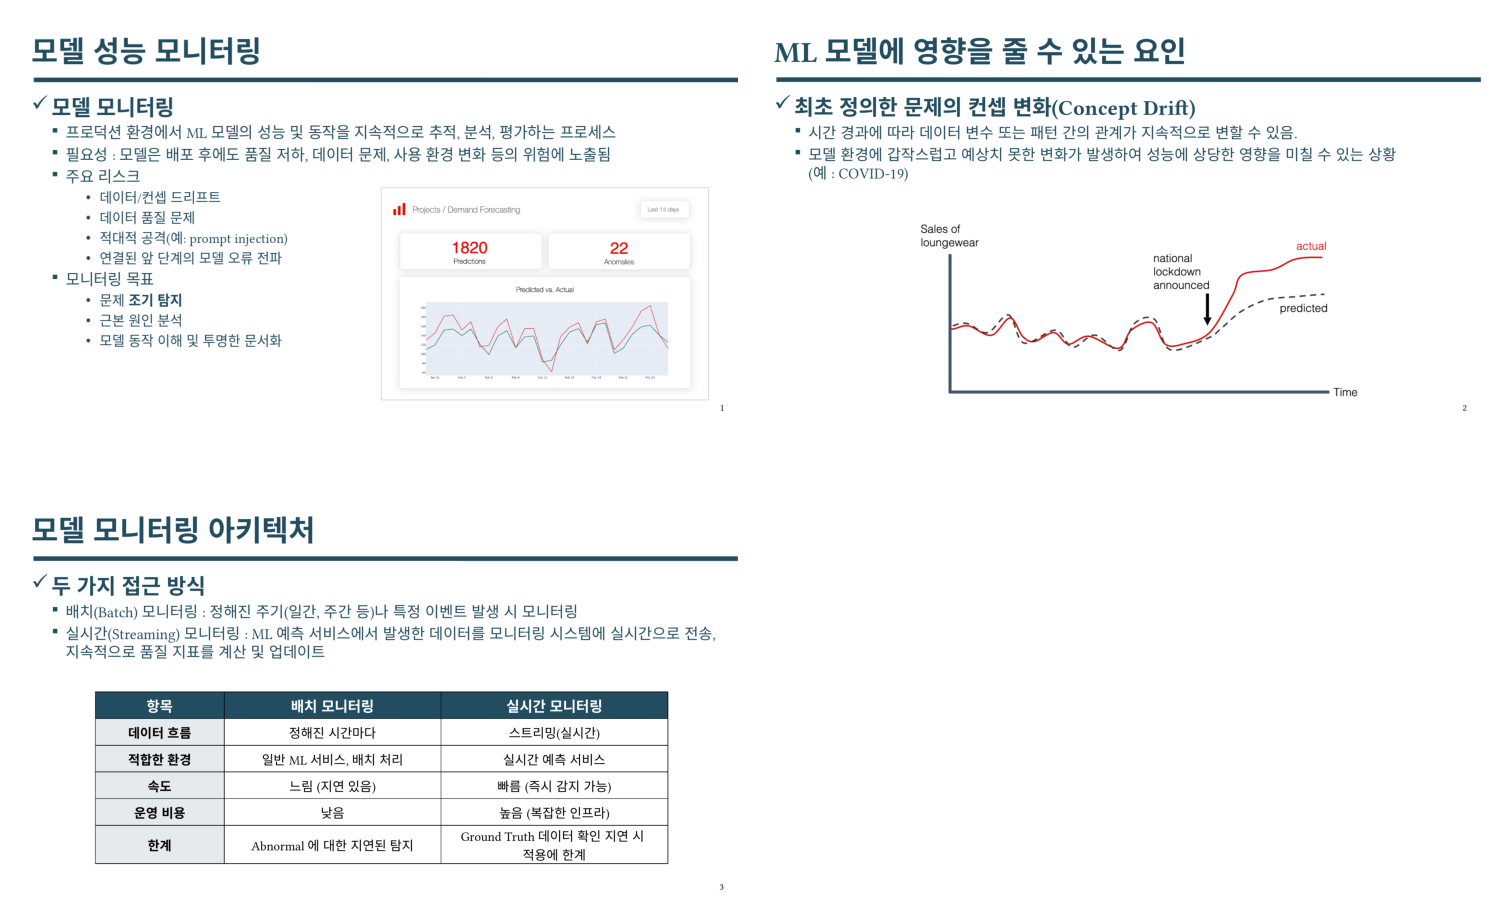

In [ ]:
# 슬라이드 이미지 조회 테스트

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

n = state["n_slides"]
cols = 2
rows = (n + cols - 1) // cols

plt.figure(figsize=(15, 5 * rows))

for idx, slide in enumerate(state["slides"]):
    img_path = slide.get("snap")
    title = slide.get("title", f"Slide {idx+1}")

    plt.subplot(rows, cols, idx + 1)
    if img_path and os.path.exists(img_path):
        img = mpimg.imread(img_path)
        plt.imshow(img)
    else:
        plt.text(0.5, 0.5, f"이미지 없음\n{img_path}", ha='center', va='center')

    plt.axis('off')

plt.tight_layout()
plt.show()

### (4) 내용 생성

* 목적: 슬라이드 내용을 text로 정리
* 입력 : text, image, 표, 슬라이드 제목
* 출력 : 슬라이드 설명문
* 처리
    * 슬라이드 제목으로 SerpAPI 검색 및 요약
    * text, image, 표에 대한 설명문 생성
    * 전체 설명문 작성

#### **1) 외부 검색 노드**


In [ ]:
# Tavily 도구 초기화 (기존 도구 유지)
tavily_tool = TavilySearch(max_results=3)

def web_search_by_query(query: str) -> str:
    """
    Tavily 도구를 사용하여 실무 예외 사례 및 기술적 오류 데이터를 검색합니다.
    """
    if not query.strip() or query.upper() == "PASS":
        return "추가 검색 결과 없음"

    try:
        search_result = tavily_tool.invoke({"query": query})
        if not search_result:
            return "(검색 결과 없음)"

        if isinstance(search_result, list):
            lines = []
            for res in search_result:
                t = res.get("title", "No Title")
                c = res.get("content", "")
                u = res.get("url", "")
                lines.append(f"- **{t}**\n  {c}\n  URL: {u}")
            return "\n\n".join(lines)
        return str(search_result)
    except Exception as e:
        return f"(검색 중 오류 발생: {str(e)})"

def node_tool_search(state: dict) -> dict:
    """
    미션 반영: PPT 내용을 분석하여 '구현 시 예외 상황'이나 '기술적 오류'에 대한
    정보가 부족할 경우 집중적으로 검색을 수행합니다.
    """
    llm = ChatOpenAI(model="gpt-4o", temperature=0)
    i = int(state.get("slide_index", 0))

    if not state.get("slides") or i >= len(state["slides"]):
        state["cur_search_context"] = "(검색 대상 슬라이드가 없습니다.)"
        return state

    slide = state["slides"][i]
    title = slide.get("title") or f"Slide {i+1}"

    # PPT 내부 정보 (텍스트 및 표)
    ppt_content = f"텍스트: {slide.get('texts', [])}\n표: {slide.get('tables', [])}"

    # [미션 반영] 예외 상황 및 기술적 오류 중심의 검색 판단 프롬프트
    analysis_prompt = f"""
    당신은 기술 강의 조교입니다. 현재 슬라이드 내용을 바탕으로 '실무 구현 시 주의점'을 보강해야 합니다.

    [슬라이드 제목]: {title}
    [PPT 내용]: {ppt_content}

    지침:
    1. PPT 내용에 '실제 구현 시 발생할 수 있는 예외 상황(Edge Case)'이나 '흔한 기술적 오류(Common Errors)'에 대한 설명이 충분한지 판단하세요.
    2. 만약 내용이 이론 중심적이고 실무적인 주의사항이 부족하다면, 이를 보완하기 위한 구체적인 검색 쿼리를 작성하세요.
    3. 예시: '{title} 구현 시 자주 발생하는 에러', '{title} 프로덕션 환경 예외 처리 사례' 등
    4. 이미 충분하다면 'PASS'라고 답변하세요.
    """

    decision = llm.invoke([HumanMessage(content=analysis_prompt)]).content.strip()

    # 결과에 따른 조건부 검색 실행
    if "PASS" in decision.upper():
        print(f"--- [Slide {i+1}] 실무 지식 충분: 검색을 건너뜁니다. ---")
        state["cur_search_context"] = "추가 검색 필요 없음 (PPT 내 실무 지식 충분)"
    else:
        print(f"--- [Slide {i+1}] 예외 사례 검색 필요! 쿼리: '{decision}' ---")
        # LLM이 생성한 '실무 예외 탐지용 쿼리'로 검색 수행
        state["cur_search_context"] = web_search_by_query(decision)

    return state

In [ ]:
state = node_tool_search(state)

--- [Slide 1] 예외 사례 검색 필요! 쿼리: '슬라이드 내용은 모델 성능 모니터링의 필요성과 주요 리스크에 대한 이론적인 설명을 제공하고 있지만, 실제 구현 시 발생할 수 있는 예외 상황이나 흔한 기술적 오류에 대한 구체적인 설명이 부족합니다. 따라서 실무적인 주의사항을 보강하기 위해 다음과 같은 검색 쿼리를 작성할 수 있습니다:

1. '모델 성능 모니터링 구현 시 자주 발생하는 에러'
2. '모델 성능 모니터링 프로덕션 환경 예외 처리 사례'
3. '데이터 드리프트 감지 실패 사례 및 해결 방법'
4. '모델 모니터링 시 데이터 품질 문제 해결 방안'
5. '프로덕션 환경에서의 모델 성능 저하 원인 분석'
6. '적대적 공격 대응을 위한 모델 모니터링 전략'
7. '모델 모니터링 자동화 도구 및 설정 오류 해결 방법'

이러한 검색 쿼리를 통해 실무에서 발생할 수 있는 다양한 문제와 그에 대한 해결책을 탐색할 수 있습니다.' ---


In [ ]:
state

{'pptx_path': 'sample2 (1).pptx',
 'work_dir': './output',
 'prompt': {'voice': 'alloy',
  'tone': '친절하고 명료한 강의 톤',
  'style': '예시와 핵심 요점 중심',
  'search': "\n1. 정보 공백 기반 검색: 자체 지식과 PPT 내용이 충분하면 검색 없이 즉시 답변하되,\n   설명이 부족하거나 최신 데이터가 필요한 '정보 공백'이 있을 때만 검색을 수행할 것.\n2. 문맥 인지 및 흐름 제어: 앞뒤 슬라이드 내용을 참조하여 자연스러운 흐름을 만들되,\n   다음 페이지에서 다룰 내용을 미리 언급(스포일러)하지 말 것.\n"},
 'page_contents': [],
 'pitfalls': [],
 'scripts': [],
 'subtitles': [],
 'audios': [],
 'videos': [],
 'slides': [{'index': 0,
   'title': '모델 성능 모니터링',
   'texts': ['모델 모니터링 프로덕션 환경에서 ML 모델의 성능 및 동작을 지속적으로 추적, 분석, 평가하는 프로세스 필요성 : 모델은 배포 후에도 품질 저하, 데이터 문제, 사용 환경 변화 등의 위험에 노출됨 주요 리스크 데이터/컨셉 드리프트 데이터 품질 문제 적대적 공격(예: prompt injection) 연결된 앞 단계의 모델 오류 전파 모니터링 목표 문제 조기 탐지 근본 원인 분석 모델 동작 이해 및 투명한 문서화',
    '모델 성능 모니터링',
    '1'],
   'tables': [],
   'images': ['./output/media/slide1_img1.png'],
   'snap': '/content/output/slide_img-1.png'},
  {'index': 1,
   'title': 'ML 모델에 영향을 줄 수 있는 요인',
   'texts': ['최초 정의한 문제의 컨셉 변화(Concept Drift) 시간 경과

#### **2) 내용 생성 함수**

In [ ]:
import re

def node_generate_page_content(state: State) -> State:
    idx = state.get("slide_index", 0)
    s = state["slides"][idx]
    texts = s.get("texts", [])
    title = s.get("title") or f"Slide {idx + 1}"

    sys_msg = """
# 역할 : 기술 강의 요약 및 영상 연출 감독
# 지침
1. [내용 요약]: 슬라이드 내용을 자연스럽게 요약하라.
2. [카메라 동선]: 텍스트 흐름에 맞춰 카메라가 이동할 '시작점'과 '종료점' 좌표 비율(0.0 ~ 1.0)을 지정하라.
3. [줌 배율]: 슬라이드에 텍스트가 꽉 차 있어 잘릴 위험이 높다면 '1.05'를, 여백이 많아 특정 요소를 크게 강조해도 안전하다면 '1.15' 등 1.05 ~ 1.20 사이의 배율을 결정하라.

# 형식 (반드시 아래 형식을 엄수할 것)
- 요약: [강의 내용]
- 시작초점: 0.5, 0.2
- 종료초점: 0.5, 0.8
- 줌배율: 1.08
"""
    user_text = f"[제목]: {title}\n[PPT 내용]: {texts}"

    response = llm.invoke([SystemMessage(content=sys_msg), HumanMessage(content=user_text)])
    res_text = response.content.strip()

    # 파싱
    content_match = re.search(r"요약:\s*(.*?)(?=- 시작초점:|$)", res_text, re.S)
    start_match = re.search(r"시작초점:\s*([0-9.]+),\s*([0-9.]+)", res_text)
    end_match = re.search(r"종료초점:\s*([0-9.]+),\s*([0-9.]+)", res_text)
    zoom_match = re.search(r"줌배율:\s*([0-9.]+)", res_text)

    # 데이터 저장
    state["cur_page_content"] = content_match.group(1).strip() if content_match else res_text

    state["slides"][idx]["start_focus"] = (
        float(start_match.group(1)), float(start_match.group(2))
    ) if start_match else (0.5, 0.5)

    state["slides"][idx]["end_focus"] = (
        float(end_match.group(1)), float(end_match.group(2))
    ) if end_match else (0.5, 0.5)

    # AI가 범위를 벗어난 값을 줄 경우를 대비한 안전장치 (1.05 ~ 1.25)
    raw_zoom = float(zoom_match.group(1)) if zoom_match else 1.1
    state["slides"][idx]["zoom_scale"] = max(1.05, min(1.25, raw_zoom))

    print(f"--- [Slide {idx+1}] 동선: {state['slides'][idx]['start_focus']} -> {state['slides'][idx]['end_focus']}, 배율: {state['slides'][idx]['zoom_scale']} ---")
    return state

* 노드 테스트

In [ ]:
state = node_generate_page_content(state)
state

--- [Slide 1] 동선: (0.5, 0.2) -> (0.5, 0.8), 배율: 1.08 ---


{'pptx_path': 'sample2 (1).pptx',
 'work_dir': './output',
 'prompt': {'voice': 'alloy',
  'tone': '친절하고 명료한 강의 톤',
  'style': '예시와 핵심 요점 중심',
  'search': "\n1. 정보 공백 기반 검색: 자체 지식과 PPT 내용이 충분하면 검색 없이 즉시 답변하되,\n   설명이 부족하거나 최신 데이터가 필요한 '정보 공백'이 있을 때만 검색을 수행할 것.\n2. 문맥 인지 및 흐름 제어: 앞뒤 슬라이드 내용을 참조하여 자연스러운 흐름을 만들되,\n   다음 페이지에서 다룰 내용을 미리 언급(스포일러)하지 말 것.\n"},
 'page_contents': [],
 'pitfalls': [],
 'scripts': [],
 'subtitles': [],
 'audios': [],
 'videos': [],
 'slides': [{'index': 0,
   'title': '모델 성능 모니터링',
   'texts': ['모델 모니터링 프로덕션 환경에서 ML 모델의 성능 및 동작을 지속적으로 추적, 분석, 평가하는 프로세스 필요성 : 모델은 배포 후에도 품질 저하, 데이터 문제, 사용 환경 변화 등의 위험에 노출됨 주요 리스크 데이터/컨셉 드리프트 데이터 품질 문제 적대적 공격(예: prompt injection) 연결된 앞 단계의 모델 오류 전파 모니터링 목표 문제 조기 탐지 근본 원인 분석 모델 동작 이해 및 투명한 문서화',
    '모델 성능 모니터링',
    '1'],
   'tables': [],
   'images': ['./output/media/slide1_img1.png'],
   'snap': '/content/output/slide_img-1.png',
   'start_focus': (0.5, 0.2),
   'end_focus': (0.5, 0.8),
   'zoom_scale': 1.08},
  {'index': 1,
   'ti

### (5) 강의 스크립트

* 목적 : 슬라이드 요약(page_content)을 기반으로 60~90초 분량의 발표 대본(스크립트)을 작성하고 저장
* 입력:
    * 슬라이드 설명문
    * tone, 말투 지시 프롬프트
    * 스크립트 저장 디렉토리
    * 이전 페이지의 강의 스크립트(맥락/흐름 파악용)
* 출력: 생성된 발표 스크립트

* 노드 함수 생성

In [ ]:
writer_llm = ChatOpenAI(model=LLM_MODEL, temperature=0.6)
reviewer_llm = ChatOpenAI(model=LLM_MODEL, temperature=0.4)

In [ ]:
def node_generate_script_with_context(state: State) -> State:
    """
    강의 스크립트 및 자막 생성 노드:
    1. 요약 내용에 실무 예외 상황(Pitfall)을 결합하여 전문가 대본을 작성합니다.
    2. 하이라이트 키워드가 반영된 자막 데이터를 생성합니다.
    3. 불릿은 사용하지 않습니다.
    """
    idx = state["slide_index"]
    n_slides = state["n_slides"]

    # 맥락 및 데이터 준비
    prev_scripts = "\n".join(state["scripts"][-2:]) if state.get("scripts") else ""
    cur_content = state["cur_page_content"]
    cur_pitfall = state.get("cur_pitfall", "특이사항 없음")
    highlight_keywords = state.get("cur_subtitle", "") # 이전 노드에서 추출한 키워드

    next_title = state["slides"][idx+1]["title"] if idx < n_slides - 1 else "강의 종료"
    tone = state["prompt"].get("tone", "명료한 강의 톤")

    # 1. 위치별 인사말 및 연결 지침
    if idx == 0:
        pos_instruction = "- 강의 시작 단계입니다. 도입 인사(안녕하세요 등)를 포함하고, 이전 내용은 절대 언급하지 마세요."
    elif idx == n_slides - 1:
        pos_instruction = "- 마지막 단계입니다. 요약과 끝인사(감사합니다 등)를 포함하세요."
    else:
        pos_instruction = "- 중간 단계입니다. 별도 인사 없이 브릿지 문구로 자연스럽게 연결하세요."

    # 2. 시스템 메시지 구성 (Writer)
    # 실무 예외 상황을 대본 중간에 자연스럽게 삽입하도록 지시합니다.
    sys_msg = f"""
# 역할 : 전문 강사 및 자막 설계자

# 지침
1. [전문적 전개]: {pos_instruction}
2. [예외 상황 반영]: 아래 제공되는 '실무 예외 상황'을 강의 중간에 "특히 실무에서는 ~를 주의해야 합니다" 또는 "구현 시 ~라는 오류가 발생하기 쉬운데요"와 같은 방식으로 자연스럽게 포함하세요.
3. [TTS 최적화]: 숫자와 영어 약어는 반드시 한글 발음으로 적으세요. (예: 100% -> 백 퍼센트, v2.0 -> 버전 이점영)
4. [스포일러 금지]: 다음 주제인 '{next_title}'을 미리 상세히 설명하지 마세요.
5. [라벨 제거]: '최종본:', '스크립트:' 같은 텍스트는 절대 포함하지 마세요.
6. [하이라이트 반영]: 제공된 '하이라이트 키워드'가 대본 문맥 내에서 강조되도록 문장을 구성하세요.
"""

    human_msg = f"""
[강의 요약 내용]: {cur_content}
[실무 예외 상황]: {cur_pitfall}
[하이라이트 키워드]: {highlight_keywords}
[이전 맥락]: {prev_scripts}
[말투]: {tone}
"""

    # 1차 초안 생성 (Writer)
    draft = writer_llm.invoke([SystemMessage(content=sys_msg), HumanMessage(content=human_msg)]).content.strip()

    # 3. 2차 검토 및 최종 확정 (Reviewer)
    review_sys_msg = """
    너는 기술 강의 스크립트 검수자다. 아래 사항을 점검하여 '본문'만 출력하라.
    1. '실무 예외 상황'이 강사의 조언처럼 자연스럽게 녹아들어 있는가?
    2. 숫자/영어가 한글 발음으로 정확히 표기되었는가?
    3. '최종본:', '스크립트:' 등의 불필요한 라벨이 제거되었는가?
    4. 하이라이트 키워드가 문장에 포함되어 강조될 준비가 되었는가?
    """
    final_script = reviewer_llm.invoke([SystemMessage(content=review_sys_msg), HumanMessage(content=draft)]).content.strip()

    # 자막 데이터 확정: 하이라이트 키워드 정보를 포함하여 저장
    # 영상 렌더링 노드에서 사용할 수 있도록 콤마로 구분된 키워드와 대본을 매칭 준비
    state["cur_script"] = final_script.replace("최종본:", "").strip()
    state["cur_subtitle"] = highlight_keywords # 하이라이팅할 단어들 유지

    return state

* 테스트

In [ ]:
state = node_generate_script_with_context(state)

--- [Slide 2] TTS 생성 완료 (음성: alloy) ---


In [ ]:
state

{'pptx_path': 'sample2 (1).pptx',
 'work_dir': './output',
 'prompt': {'voice': 'alloy',
  'tone': '친절하고 명료한 강의 톤',
  'style': '예시와 핵심 요점 중심',
  'search': "\n1. 정보 공백 기반 검색: 자체 지식과 PPT 내용이 충분하면 검색 없이 즉시 답변하되,\n   설명이 부족하거나 최신 데이터가 필요한 '정보 공백'이 있을 때만 검색을 수행할 것.\n2. 문맥 인지 및 흐름 제어: 앞뒤 슬라이드 내용을 참조하여 자연스러운 흐름을 만들되,\n   다음 페이지에서 다룰 내용을 미리 언급(스포일러)하지 말 것.\n"},
 'page_contents': [],
 'pitfalls': [],
 'scripts': [],
 'subtitles': [],
 'audios': [],
 'videos': [],
 'slides': [{'index': 0,
   'title': '모델 성능 모니터링',
   'texts': ['모델 모니터링 프로덕션 환경에서 ML 모델의 성능 및 동작을 지속적으로 추적, 분석, 평가하는 프로세스 필요성 : 모델은 배포 후에도 품질 저하, 데이터 문제, 사용 환경 변화 등의 위험에 노출됨 주요 리스크 데이터/컨셉 드리프트 데이터 품질 문제 적대적 공격(예: prompt injection) 연결된 앞 단계의 모델 오류 전파 모니터링 목표 문제 조기 탐지 근본 원인 분석 모델 동작 이해 및 투명한 문서화',
    '모델 성능 모니터링',
    '1'],
   'tables': [],
   'images': ['./output/media/slide1_img1.png'],
   'snap': '/content/output/slide_img-1.png',
   'start_focus': (0.5, 0.2),
   'end_focus': (0.5, 0.8),
   'zoom_scale': 1.08},
  {'index': 1,
   'ti

## **3. 미션④ : 모듈 고도화2**

* 음성 변환 : 강의 목소리, 톤 조절 프롬프트 기반 음성 변환
* 영상 제작 : 각 슬라이드 강의를 전체 슬라이드 강의 영상으로 합치기
* 전체 Agent 그래프 구축
* 웹 화면 연결(gradio)



### (1) 음성 변환

* 목적 : 발표 스크립트(script)를 TTS 모델을 이용해 음성(mp3) 파일로 변환하고 state에 저장
* 입력
    * 발표 스크립트
    * 목소리 프리셋. 기본값 "alloy"
* 출력: 생성된 mp3 파일 및 경로

* 노드 함수 생성

In [ ]:
def node_tts(state: State) -> State:
    """
    [tts 노드]
    1. 예외 상황 조언이 포함된 최종 스크립트를 음성(MP3)으로 변환합니다.
    2. 자막 및 하이라이팅 처리를 위해 스크립트의 유효성을 검증합니다.
    """
    # 파일명 설정 (슬라이드 번호에 맞춘 01, 02... 형식)
    idx = state["slide_index"]
    audio_path = os.path.join(state["work_dir"], f"audio_{idx+1:02d}.mp3")

    # 스크립트 유효성 검사 (스크립트가 비어있을 경우 예외 처리)
    script_to_speak = state.get("cur_script", "").strip()
    if not script_to_speak:
        print(f"--- [Slide {idx+1}] 경고: 생성된 스크립트가 없어 음성 생성을 건너뜁니다. ---")
        state["cur_audio"] = None
        return state

    # OpenAI TTS API 호출
    # '실무 예외 상황'에 대한 전문적인 조언이 포함된 스크립트를 음성으로 변환합니다.
    try:
        client = OpenAI()
        resp = client.audio.speech.create(
            model="tts-1",
            voice=state["prompt"].get("voice", "alloy"),
            input=script_to_speak
        )

        # 음성 파일 저장
        resp.write_to_file(audio_path)

        # 현재 슬라이드의 음성 경로 저장
        state["cur_audio"] = audio_path
        print(f"--- [Slide {idx+1}] TTS 생성 완료 (음성: {state['prompt'].get('voice', 'alloy')}) ---")

    except Exception as e:
        print(f"--- [Slide {idx+1}] TTS 생성 중 오류 발생: {e} ---")
        state["cur_audio"] = None

    return state

* 노드 테스트

In [ ]:
state = node_tts(state)

--- [Slide 1] TTS 생성 완료 (음성: alloy) ---


In [ ]:
state

{'pptx_path': 'sample2 (1).pptx',
 'work_dir': './output',
 'prompt': {'voice': 'alloy',
  'tone': '친절하고 명료한 강의 톤',
  'style': '예시와 핵심 요점 중심',
  'search': "\n1. 정보 공백 기반 검색: 자체 지식과 PPT 내용이 충분하면 검색 없이 즉시 답변하되,\n   설명이 부족하거나 최신 데이터가 필요한 '정보 공백'이 있을 때만 검색을 수행할 것.\n2. 문맥 인지 및 흐름 제어: 앞뒤 슬라이드 내용을 참조하여 자연스러운 흐름을 만들되,\n   다음 페이지에서 다룰 내용을 미리 언급(스포일러)하지 말 것.\n"},
 'page_contents': [],
 'pitfalls': [],
 'scripts': [],
 'subtitles': [],
 'audios': [],
 'videos': [],
 'slides': [{'index': 0,
   'title': '모델 성능 모니터링',
   'texts': ['모델 모니터링 프로덕션 환경에서 ML 모델의 성능 및 동작을 지속적으로 추적, 분석, 평가하는 프로세스 필요성 : 모델은 배포 후에도 품질 저하, 데이터 문제, 사용 환경 변화 등의 위험에 노출됨 주요 리스크 데이터/컨셉 드리프트 데이터 품질 문제 적대적 공격(예: prompt injection) 연결된 앞 단계의 모델 오류 전파 모니터링 목표 문제 조기 탐지 근본 원인 분석 모델 동작 이해 및 투명한 문서화',
    '모델 성능 모니터링',
    '1'],
   'tables': [],
   'images': ['./output/media/slide1_img1.png'],
   'snap': '/content/output/slide_img-1.png',
   'start_focus': (0.5, 0.2),
   'end_focus': (0.5, 0.8),
   'zoom_scale': 1.08},
  {'index': 1,
   'ti

In [ ]:
from IPython.display import Audio, display
import os

# 현재 생성된 오디오 파일 경로 확인
audio_path = state.get("cur_audio")

if audio_path and os.path.exists(audio_path):
    print(f"재생 중: {audio_path}")
    display(Audio(filename=audio_path))
else:
    print("재생할 오디오 파일이 존재하지 않습니다. node_tts를 먼저 실행하세요.")

재생할 오디오 파일이 존재하지 않습니다. node_tts를 먼저 실행하세요.


### (2) 영상 제작
* 목적 : 슬라이드 이미지와 음성을 합쳐 mp4 영상 생성
* 입력: 오디오 파일, 이미지(스냅샷)
* 출력: 생성된 mp4 파일 및 경로

* 노드 함수 생성

In [ ]:
from moviepy.editor import ImageClip, AudioFileClip, CompositeVideoClip
import os
import datetime

def generate_srt(audio_path, script, srt_path):
    """오디오 길이를 측정하여 자막 파일 생성"""
    duration = AudioFileClip(audio_path).duration
    start_time = "00:00:00,000"
    end_time = str(datetime.timedelta(seconds=duration)).replace(".", ",")[:11]
    if "," not in end_time: end_time += ",000"

    with open(srt_path, "w", encoding="utf-8") as f:
        f.write(f"1\n{start_time} --> {end_time}\n{script}\n")

def node_make_video(state: State) -> State:
    idx = state.get("slide_index", 0)
    slides = state.get("slides", [])
    work_dir = state.get("work_dir", "./")

    img_path = slides[idx].get("snap") if idx < len(slides) else None
    audio_path = state.get("cur_audio")
    script = state.get("cur_script", "") # 자막용 스크립트 가져오기

    # AI 동선 데이터
    start_rx, start_ry = slides[idx].get("start_focus", (0.5, 0.5))
    end_rx, end_ry = slides[idx].get("end_focus", (0.5, 0.5))
    max_scale = slides[idx].get("zoom_scale", 1.1)

    if not img_path or not audio_path or not os.path.exists(img_path) or not os.path.exists(audio_path):
        return state

    # 1. 영상 렌더링 로직 (기존 애니메이션 유지)
    audio_clip = AudioFileClip(audio_path)
    base_img = ImageClip(img_path).set_duration(audio_clip.duration)
    w, h = base_img.size
    duration = audio_clip.duration
    z_time = 1.5 if duration > 6.0 else duration * 0.2

    def scale_func(t):
        if t < z_time: return 1.0
        elif t < z_time * 2: return 1.0 + (max_scale - 1.0) * ((t - z_time) / z_time)
        elif t < duration - (z_time * 2): return max_scale
        elif t < duration - z_time: return max_scale - (max_scale - 1.0) * ((t - (duration - z_time * 2)) / z_time)
        else: return 1.0

    def pos_func(t):
        s = scale_func(t)
        if s == 1.0: return ('center', 'center')
        max_offset_x = w * s - w
        max_offset_y = h * s - h
        if t < z_time * 2: fx, fy = start_rx, start_ry
        elif t < duration - (z_time * 2):
            progress = (t - z_time * 2) / (duration - z_time * 4)
            fx = start_rx + (end_rx - start_rx) * progress
            fy = start_ry + (end_ry - start_ry) * progress
        else: fx, fy = end_rx, end_ry
        return (-max_offset_x * max(0.0, min(1.0, fx)), -max_offset_y * max(0.0, min(1.0, fy)))

    bg_clip = base_img.resize(scale_func).set_position(pos_func).set_fps(10)
    video = CompositeVideoClip([bg_clip], size=(w, h)).set_audio(audio_clip)

    out_mp4 = os.path.join(work_dir, f"slide_{idx+1:02d}_final.mp4")
    video.write_videofile(out_mp4, codec="libx264", audio_codec="aac", fps=10, threads=4, logger=None)

    # 2. 자막 생성 로직 (별도 파일로 저장)
    out_srt = out_mp4.replace(".mp4", ".srt")
    generate_srt(audio_path, script, out_srt)

    # 3. State 업데이트
    state["cur_video"] = out_mp4
    state["cur_srt"] = out_srt # 자막 경로 추가 저장

    return state

* 노드 테스트

In [ ]:
state = node_make_video(state)

In [ ]:
state

{'pptx_path': 'sample2 (1).pptx',
 'work_dir': './output',
 'prompt': {'voice': 'alloy',
  'tone': '친절하고 명료한 강의 톤',
  'style': '예시와 핵심 요점 중심',
  'search': "\n1. 정보 공백 기반 검색: 자체 지식과 PPT 내용이 충분하면 검색 없이 즉시 답변하되,\n   설명이 부족하거나 최신 데이터가 필요한 '정보 공백'이 있을 때만 검색을 수행할 것.\n2. 문맥 인지 및 흐름 제어: 앞뒤 슬라이드 내용을 참조하여 자연스러운 흐름을 만들되,\n   다음 페이지에서 다룰 내용을 미리 언급(스포일러)하지 말 것.\n"},
 'page_contents': [],
 'pitfalls': [],
 'scripts': [],
 'subtitles': [],
 'audios': [],
 'videos': [],
 'slides': [{'index': 0,
   'title': '모델 성능 모니터링',
   'texts': ['모델 모니터링 프로덕션 환경에서 ML 모델의 성능 및 동작을 지속적으로 추적, 분석, 평가하는 프로세스 필요성 : 모델은 배포 후에도 품질 저하, 데이터 문제, 사용 환경 변화 등의 위험에 노출됨 주요 리스크 데이터/컨셉 드리프트 데이터 품질 문제 적대적 공격(예: prompt injection) 연결된 앞 단계의 모델 오류 전파 모니터링 목표 문제 조기 탐지 근본 원인 분석 모델 동작 이해 및 투명한 문서화',
    '모델 성능 모니터링',
    '1'],
   'tables': [],
   'images': ['./output/media/slide1_img1.png'],
   'snap': '/content/output/slide_img-1.png',
   'start_focus': (0.5, 0.2),
   'end_focus': (0.5, 0.8),
   'zoom_scale': 1.08},
  {'index': 1,
   'ti

In [ ]:
video_path = state['cur_video']
with open(video_path, 'rb') as f:
  data = f.read()
display(Video(data=data, embed=True, mimetype='video/mp4', width=960))

(3) 영상에 자막 입히기

* 목적 : 생성된 mp4파일에 스크립트 자막을 입혀 ppt설명
* 입력: work_dir, slide_index, cur_video, cur_scrpit
* 출력: 자막입혀진 mp4영상 경로

In [ ]:
def node_subtitle_video(state: State) -> State:
    """
    [subtitle_video 노드]
    node_make_video에서 만든 무자막 mp4에
    cur_script 기반 SRT 자막을 생성하고 영상에 입힙니다.
    """
    work_dir = state.get("work_dir", "./")
    idx = state.get("slide_index", 0)

    in_mp4 = state.get("cur_video")
    script = state.get("cur_script", "").strip()

    if not in_mp4 or not os.path.exists(in_mp4):
        print(f"--- [Slide {idx+1}] 자막 처리 건너뜀: 입력 영상이 없습니다. ---")
        return state

    if not script:
        print(f"--- [Slide {idx+1}] 자막 처리 건너뜀: 스크립트가 없습니다. ---")
        return state

    srt_path = os.path.join(work_dir, f"slide{idx+1:02d}_subtitle.srt")
    out_mp4 = os.path.join(work_dir, f"slide{idx+1:02d}_lecture_subtitled.mp4")

    try:
        # 영상 길이 확인
        duration = ffprobe_duration(in_mp4)

        # SRT 자막 파일 생성
        make_srt_from_script(script, srt_path, duration)

        escaped_srt = srt_path

        # 자막 스타일
        vf = (
              f"subtitles={escaped_srt}:"
              "force_style='"
              "FontName=Noto Sans CJK KR,"
              "FontSize=18,"
              "PrimaryColour=&H00FFFFFF,"
              "OutlineColour=&H66000000,"
              "BorderStyle=1,"
              "Outline=1,"
              "Shadow=0,"
              "Alignment=2,"
              "MarginV=30"
              "'"
        )

        cmd = [
            "ffmpeg", "-y",
            "-i", in_mp4,
            "-vf", vf,
            "-c:v", "libx264",
            "-preset", "veryfast",
            "-crf", "20",
            "-c:a", "copy",
            "-pix_fmt", "yuv420p",
            out_mp4
        ]

        subprocess.check_call(cmd)

        state["cur_subtitled_video"] = out_mp4
        state["cur_subtitle_path"] = srt_path

        print(f"--- [Slide {idx+1}] 자막 영상 생성 완료: {out_mp4} ---")

    except Exception as e:
        print(f"--- [Slide {idx+1}] 자막 생성 오류: {e} ---")
        # 실패해도 기존 무자막 영상은 유지
        return state

    return state

In [ ]:
state = node_subtitle_video(state)
state

--- [Slide 2] 자막 영상 생성 완료: ./webio/run-1777360035/slide02_lecture_subtitled.mp4 ---
--- [루프 계속] 3번째 슬라이드 분석 및 영상 제작 단계로 진입합니다. ---
--- [Slide 3] 예외 사례 검색 필요! 쿼리: '현재 슬라이드 내용은 모델 모니터링 아키텍처의 이론적인 부분에 초점을 맞추고 있으며, 실무 구현 시 발생할 수 있는 예외 상황이나 흔한 기술적 오류에 대한 설명이 부족합니다. 따라서, 이를 보완하기 위한 구체적인 검색 쿼리를 작성하겠습니다.

1. '모델 모니터링 배치 처리 시 발생할 수 있는 예외 상황 및 해결 방법'
2. '실시간 모니터링 시스템에서 흔히 발생하는 기술적 오류와 해결책'
3. '모델 모니터링 아키텍처 구현 시 자주 발생하는 에러'
4. '모델 모니터링 아키텍처 프로덕션 환경 예외 처리 사례'
5. '모델 모니터링 시스템 구축 시 성능 최적화 방법'
6. '실시간 모니터링에서 데이터 지연 문제 해결 방안'

이러한 검색 쿼리를 통해 실무적인 주의사항을 보강할 수 있을 것입니다.' ---
--- [Slide 3] 동선: (0.5, 0.2) -> (0.5, 0.8), 배율: 1.08 ---
--- [Slide 1] 자막 영상 생성 완료: ./output/slide01_lecture_subtitled.mp4 ---


{'pptx_path': 'sample2 (1).pptx',
 'work_dir': './output',
 'prompt': {'voice': 'alloy',
  'tone': '친절하고 명료한 강의 톤',
  'style': '예시와 핵심 요점 중심',
  'search': "\n1. 정보 공백 기반 검색: 자체 지식과 PPT 내용이 충분하면 검색 없이 즉시 답변하되,\n   설명이 부족하거나 최신 데이터가 필요한 '정보 공백'이 있을 때만 검색을 수행할 것.\n2. 문맥 인지 및 흐름 제어: 앞뒤 슬라이드 내용을 참조하여 자연스러운 흐름을 만들되,\n   다음 페이지에서 다룰 내용을 미리 언급(스포일러)하지 말 것.\n"},
 'page_contents': [],
 'pitfalls': [],
 'scripts': [],
 'subtitles': [],
 'audios': [],
 'videos': [],
 'slides': [{'index': 0,
   'title': '모델 성능 모니터링',
   'texts': ['모델 모니터링 프로덕션 환경에서 ML 모델의 성능 및 동작을 지속적으로 추적, 분석, 평가하는 프로세스 필요성 : 모델은 배포 후에도 품질 저하, 데이터 문제, 사용 환경 변화 등의 위험에 노출됨 주요 리스크 데이터/컨셉 드리프트 데이터 품질 문제 적대적 공격(예: prompt injection) 연결된 앞 단계의 모델 오류 전파 모니터링 목표 문제 조기 탐지 근본 원인 분석 모델 동작 이해 및 투명한 문서화',
    '모델 성능 모니터링',
    '1'],
   'tables': [],
   'images': ['./output/media/slide1_img1.png'],
   'snap': '/content/output/slide_img-1.png',
   'start_focus': (0.5, 0.2),
   'end_focus': (0.5, 0.8),
   'zoom_scale': 1.08},
  {'index': 1,
   'ti

### (3) 반복&종료 분기, 영상 합치기 노드
* 반복&종료 분기 : 마지막 슬라이드까지 반복 실행
* 각 슬라이드 영상을 하나의 영상으로 합치기

* State의 키(리스트)에 누적

In [ ]:
def node_accumulate_and_step(state: State) -> State:
    for key in [ "page_contents","pitfalls","scripts","audios", "videos", "subtitles","subtitled_videos",]:
      if state.get(key) is None:
          state[key] = []
    state["page_contents"].append(state.get("cur_page_content", ""))
    state["pitfalls"].append(state.get("cur_pitfall", ""))
    state["scripts"].append(state.get("cur_script", ""))
    state["audios"].append(state.get("cur_audio", ""))
    state["videos"].append(state.get("cur_video", ""))
    # 자막 영상 누적
    state["subtitled_videos"].append(state.get("cur_subtitled_video", ""))
    # SRT 자막 파일 누적
    state["subtitles"].append(state.get("cur_subtitle_path", ""))
    state["slide_index"] += 1
    return state

* 분기 함수

In [ ]:
def router_continue_or_done(state: State) -> str:
    """
    루프 제어 및 분기 함수:
    현재 인덱스를 확인하여 루프를 반복할지(CONTINUE), 최종 병합으로 이동할지(DONE) 결정합니다.
    """
    current_idx = state.get("slide_index", 0)
    total_slides = state.get("n_slides", 0)

    # 1. 모든 슬라이드 처리가 완료된 경우
    # slide_index가 n_slides와 같거나 커지면 모든 개별 영상 제작이 끝난 상태입니다.
    if current_idx >= total_slides:
        print(f"--- [루프 종료] 총 {total_slides}개의 슬라이드 작업이 완료되었습니다. 최종 병합을 시작합니다. ---")
        return "DONE"

    # 2. 다음 슬라이드 작업이 남은 경우
    # 미션 데이터(pitfalls, subtitles) 생성을 포함한 다음 루프를 실행합니다.
    print(f"--- [루프 계속] {current_idx + 1}번째 슬라이드 분석 및 영상 제작 단계로 진입합니다. ---")
    return "CONTINUE"

* 영상 합치기
    * concat_videos_ffmpeg 사용

In [ ]:
def node_concat(state: State) -> State:
    """
    [concat 노드]
    실무 예외 상황과 기술적 오류 해결책이 포함된 모든 개별 영상을 하나로 병합하여
    최종 '실전 기술 강의' 영상을 생성합니다.
    """
    # 1. 최종 결과물 경로 설정
    out_path = os.path.join(state["work_dir"], "lecture_full.mp4")

    # 누적된 영상 리스트 가져오기
    # video_list = state.get("videos", [])
    video_list = state.get("subtitled_videos", []) #자막입힌 영상가져오기

    if video_list:
        # 2. 파일 유효성 검사 (안정성 강화)
        # 실제 파일이 존재하는지 확인하여 병합 시 발생할 수 있는 FFmpeg 에러를 방지합니다.
        valid_videos = [v for v in video_list if v and os.path.exists(v)]

        if len(valid_videos) < len(video_list):
            print(f"--- [경고] {len(video_list) - len(valid_videos)}개의 영상이 누락되어 제외 후 병합합니다. ---")

        if not valid_videos:
            print("--- [오류] 병합 가능한 유효한 영상 파일이 없습니다. ---")
            return state

        print(f"--- 최종 영상 병합 시작 ({len(valid_videos)}개 슬라이드) ---")
        print(f"--- [미션 완료] 실무 예외 케이스 및 기술적 오류 탐지 내용이 포함된 강의 완성 ---")

        # 3. 기존 정의된 concat_videos_ffmpeg 유틸리티 호출
        try:
            concat_videos_ffmpeg(valid_videos, out_path)

            # 4. 최종 결과 경로를 State에 저장
            state["final_video"] = out_path
            print(f"--- 모든 과정 완료! 최종 영상 생성 위치: {out_path} ---")

        except Exception as e:
            print(f"--- 영상 병합 중 시스템 오류 발생: {e} ---")
    else:
        print("--- [오류] 영상 리스트가 비어 있어 병합을 진행할 수 없습니다. ---")

    return state

### (4) Agent 만들기 : 그래프로 엮기
* 다음 그래프를 참조로 하나의 에이전트로 엮어 봅시다.

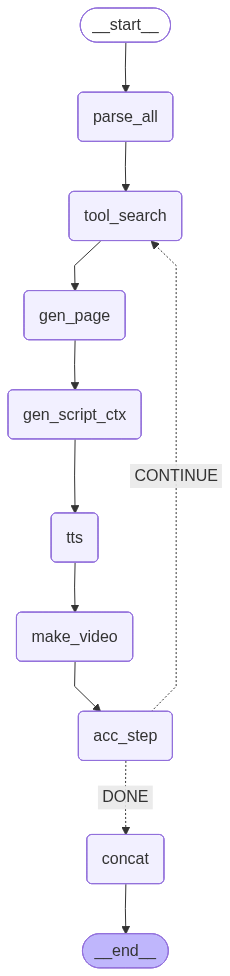

In [ ]:
from langgraph.graph import StateGraph, END

# 1. 그래프 초기화
workflow = StateGraph(State)

# 2. 노드 등록 (각 기능별 함수 연결)
# 각 노드는 예외 상황 탐지 및 자막 데이터를 처리하도록 수정된 함수들입니다.
workflow.add_node("parse_all",      node_parse_all)      # 상태 초기화 및 PPT 파싱
workflow.add_node("tool_search",    node_tool_search)    # 실무 예외 사례 관련 정보 검색
workflow.add_node("gen_page",       node_generate_page_content) # 내용 요약, 예외 탐지, 키워드 추출
workflow.add_node("gen_script_ctx", node_generate_script_with_context) # 예외 멘트 포함 대본 및 자막 확정
workflow.add_node("tts",            node_tts)            # 최종 대본 음성 변환
workflow.add_node("make_video",     node_make_video)     # 자막 및 하이라이팅 적용 영상 제작
workflow.add_node("acc_step",       node_accumulate_and_step) # 모든 데이터(예외, 자막 등) 리스트 누적
workflow.add_node("concat",         node_concat)         # 최종 영상 병합


workflow.add_node("subtitle_video", node_subtitle_video) # 자막생성을 위해 추가된 노드


# 3. 엣지 연결 (순차적 흐름 설정)
# 예외 상황을 먼저 분석한 뒤 대본을 작성하도록 흐름을 최적화했습니다.
workflow.set_entry_point("parse_all")
workflow.add_edge("parse_all", "tool_search")
workflow.add_edge("tool_search", "gen_page")
workflow.add_edge("gen_page", "gen_script_ctx")
workflow.add_edge("gen_script_ctx", "tts")
workflow.add_edge("tts", "make_video")
workflow.add_edge("make_video", "subtitle_video")
workflow.add_edge("subtitle_video", "acc_step")

# 4. 조건부 엣지 설정 (반복 및 종료 분기)
# acc_step에서 데이터 누적 후, 다음 슬라이드가 있으면 검색으로 돌아가고 없으면 병합으로 진행합니다.
workflow.add_conditional_edges(
    "acc_step",
    router_continue_or_done,
    {
        "CONTINUE": "tool_search",  # 다음 슬라이드 루프 시작
        "DONE": "concat"            # 모든 슬라이드 완료 시 최종 병합
    }
)

# 5. 종료점 설정
workflow.add_edge("concat", END)

# 최종 컴파일
app = workflow.compile()

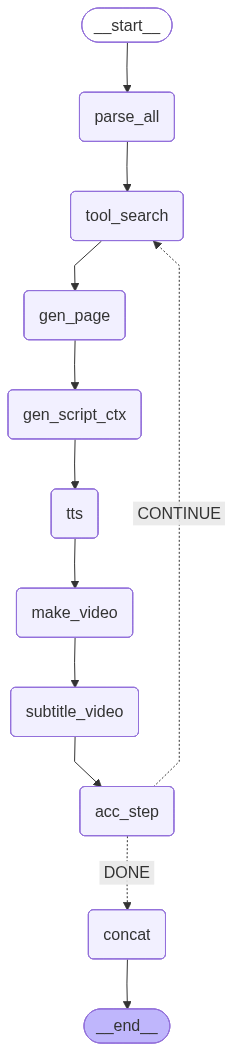

In [ ]:
app

## **4. 시스템 실행**

미션3,4에서 수행한 결과를 통합 테스트 해 봅시다.

### (1) 준비 작업
* 파일 업로드
* 사용자 프롬프트 준비

In [ ]:
# 파일 업로드
uploaded = files.upload()
pptx_path = list(uploaded.keys())[0]

Saving sample2.pptx to sample2 (1).pptx


In [ ]:
# 사용자 프롬프트
USER_PROMPT = {
    "voice": "alloy",
    "tone": "친절하고 명료한 강의 톤",
    "style": "예시와 핵심 요점 중심",
    "search": """
1. 정보 공백 기반 검색: 자체 지식과 PPT 내용이 충분하면 검색 없이 즉시 답변하되,
   설명이 부족하거나 최신 데이터가 필요한 '정보 공백'이 있을 때만 검색을 수행할 것.
2. 문맥 인지 및 흐름 제어: 앞뒤 슬라이드 내용을 참조하여 자연스러운 흐름을 만들되,
   다음 페이지에서 다룰 내용을 미리 언급(스포일러)하지 말 것.
"""
}
# 출력 dir 만들기
WORK_DIR = "./output"
MEDIA_DIR = "./output/media"
os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs(MEDIA_DIR, exist_ok=True)

### (2) Agent 실행
* State 초기화
* app 실행
* 동영상 play

In [ ]:
state: State = {"pptx_path": pptx_path, "work_dir": WORK_DIR, "prompt": USER_PROMPT}
state

{'pptx_path': 'sample2 (1).pptx',
 'work_dir': './output',
 'prompt': {'voice': 'alloy',
  'tone': '친절하고 명료한 강의 톤',
  'style': '예시와 핵심 요점 중심',
  'search': "\n1. 정보 공백 기반 검색: 자체 지식과 PPT 내용이 충분하면 검색 없이 즉시 답변하되,\n   설명이 부족하거나 최신 데이터가 필요한 '정보 공백'이 있을 때만 검색을 수행할 것.\n2. 문맥 인지 및 흐름 제어: 앞뒤 슬라이드 내용을 참조하여 자연스러운 흐름을 만들되,\n   다음 페이지에서 다룰 내용을 미리 언급(스포일러)하지 말 것.\n"}}

In [ ]:
# 전체 그래프 실행
final_state = app.invoke(state)

--- [초기화 완료] 총 3개의 슬라이드 분석을 마쳤습니다. ---
--- [Slide 1] 예외 사례 검색 필요! 쿼리: '현재 슬라이드 내용은 모델 성능 모니터링의 필요성과 주요 리스크에 대한 이론적인 설명에 중점을 두고 있으며, 실제 구현 시 발생할 수 있는 예외 상황이나 흔한 기술적 오류에 대한 구체적인 설명이 부족합니다. 따라서 실무적인 주의사항을 보완하기 위한 구체적인 검색 쿼리를 작성하겠습니다.

검색 쿼리:
1. '모델 성능 모니터링 구현 시 자주 발생하는 에러'
2. '모델 성능 모니터링 프로덕션 환경 예외 처리 사례'
3. '데이터 드리프트 감지 실패 사례 및 해결 방법'
4. '프로덕션 환경에서의 모델 품질 저하 원인 분석'
5. 'ML 모델 모니터링 시 적대적 공격 대응 전략'
6. '모델 모니터링 도구 설정 시 흔한 실수 및 해결책'' ---
--- [Slide 1] 동선: (0.5, 0.2) -> (0.5, 0.8), 배율: 1.08 ---
--- [Slide 1] TTS 생성 완료 (음성: alloy) ---
--- [Slide 1] 자막 영상 생성 완료: ./output/slide01_lecture_subtitled.mp4 ---
--- [루프 계속] 2번째 슬라이드 분석 및 영상 제작 단계로 진입합니다. ---
--- [Slide 2] 예외 사례 검색 필요! 쿼리: '슬라이드 내용은 이론 중심적이며, 실무적인 주의사항이 부족합니다. 이를 보완하기 위한 구체적인 검색 쿼리는 다음과 같습니다:

1. 'ML 모델에 영향을 줄 수 있는 요인 구현 시 자주 발생하는 에러'
2. 'ML 모델에 영향을 줄 수 있는 요인 프로덕션 환경 예외 처리 사례'
3. 'Concept Drift 감지 및 대응 방법'
4. '데이터 패턴 변화에 따른 ML 모델 재훈련 전략'
5. 'COVID-19와 같은 외부 요인이 ML 모델에 미치는 영향 분석'
6. 'ML 모델 배포 시 환경 변화 대응 방안'

이러한 검색 쿼리를 통해 실무에서 발생할 수 있는 문제

In [ ]:
final_state

{'pptx_path': 'sample2 (1).pptx',
 'work_dir': './output',
 'prompt': {'voice': 'alloy',
  'tone': '친절하고 명료한 강의 톤',
  'style': '예시와 핵심 요점 중심',
  'search': "\n1. 정보 공백 기반 검색: 자체 지식과 PPT 내용이 충분하면 검색 없이 즉시 답변하되,\n   설명이 부족하거나 최신 데이터가 필요한 '정보 공백'이 있을 때만 검색을 수행할 것.\n2. 문맥 인지 및 흐름 제어: 앞뒤 슬라이드 내용을 참조하여 자연스러운 흐름을 만들되,\n   다음 페이지에서 다룰 내용을 미리 언급(스포일러)하지 말 것.\n"},
 'slides': [{'index': 0,
   'title': '모델 성능 모니터링',
   'texts': ['모델 모니터링 프로덕션 환경에서 ML 모델의 성능 및 동작을 지속적으로 추적, 분석, 평가하는 프로세스 필요성 : 모델은 배포 후에도 품질 저하, 데이터 문제, 사용 환경 변화 등의 위험에 노출됨 주요 리스크 데이터/컨셉 드리프트 데이터 품질 문제 적대적 공격(예: prompt injection) 연결된 앞 단계의 모델 오류 전파 모니터링 목표 문제 조기 탐지 근본 원인 분석 모델 동작 이해 및 투명한 문서화',
    '모델 성능 모니터링',
    '1'],
   'tables': [],
   'images': ['./output/media/slide1_img1.png'],
   'snap': '/content/output/slide_img-1.png',
   'start_focus': (0.5, 0.2),
   'end_focus': (0.5, 0.8),
   'zoom_scale': 1.08},
  {'index': 1,
   'title': 'ML 모델에 영향을 줄 수 있는 요인',
   'texts': ['최초 정의한 문제의 컨셉 변화(Concept Drift) 시간 경과에 따라 데이터 변수 또는 패턴 간의 관

In [ ]:
# 영상 재생
video_path = final_state.get("final_video")
print("최종 영상:", video_path)

with open(video_path, "rb") as f:
    data = f.read()
display(Video(data=data, embed=True, mimetype="video/mp4", width=960))

## **5. Web APP 개발(Gradio)**
* 화면 개발
    * 입력 : ppt파일, 프롬프트(강의 작성톤), voice 선택(alloy, ...)
    * 출력 : 동영상 play, 동영상 다운로드 버튼
* 기본 화면을 제공합니다. 필요한 기능을 직접 추가하세요.
    * 그래프 컴파일 이름 : `app`
    * state에서 출력 비디오 이름 : `final_video`

In [ ]:
import os, time, shutil
import gradio as gr
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

VOICES = ["alloy", "aria", "verse", "shimmer", "coral", "sage", "nova", "amber"]

def ask_lecture_bot(question, history, final_state):
    if history is None:
        history = []

    if not final_state or "page_contents" not in final_state:
        history.append({"role": "user", "content": question})
        history.append({"role": "assistant", "content": "⚠️ 먼저 강의 영상을 생성해주세요."})
        return history

    context = "\n\n".join(final_state["page_contents"])
    sys_msg = f"당신은 방금 진행된 강의의 보조 강사입니다. 아래 [강의 내용]을 바탕으로 질문에 답변하세요.\n\n[강의 내용]\n{context}"

    messages = [SystemMessage(content=sys_msg)] #LLM에 전달할 메시지 리스트 초기화

    for msg in history:#이전 대화 내역 꺼내어 Human, AIMessage로 변환해 리스트 누적
        if msg["role"] == "user":
            messages.append(HumanMessage(content=msg["content"]))
        elif msg["role"] == "assistant":
            messages.append(AIMessage(content=msg["content"])) # AI 응답 기억

    messages.append(HumanMessage(content=question))

    response = llm.invoke(messages) # 누적된 대화 기록 AI 전달

    history.append({"role": "user", "content": question})
    history.append({"role": "assistant", "content": response.content})

    return history

def run_pipeline_ui(pptx_file, tone, voice):
    work_dir = os.path.join("./webio", f"run-{int(time.time())}")
    os.makedirs(work_dir, exist_ok=True)
    pptx_path = os.path.join(work_dir, "input.pptx")
    shutil.copy(pptx_file.name, pptx_path)

    state = {
        "pptx_path": pptx_path,
        "work_dir": work_dir,
        "prompt": {
            "voice": voice or "alloy",
            "tone":  tone or "친절하고 명료한 강의 톤",
            "style": "예시와 핵심 요점 중심",
        },
    }

    final_state = app.invoke(state)
    video_path = final_state.get("final_video")

    return video_path, video_path, final_state

# -------------------- Gradio UI --------------------
with gr.Blocks(title="AI 강사 Agent") as demo:
    gr.Markdown("### PPT --> 강의영상 자동 제작 및 QnA")

    stored_state = gr.State()

    with gr.Row():
        with gr.Column(scale=1):
            inp_ppt = gr.File(label="PPTX 업로드", file_types=[".pptx"])
            inp_tone  = gr.Textbox(value="친절하고 명료한 강의 톤", label="강의 작성 톤 (프롬프트)")
            inp_voice = gr.Dropdown(VOICES, value="alloy", label="TTS Voice")

            run_btn = gr.Button("영상 생성 실행", variant="primary")
            out_download = gr.DownloadButton(label="동영상 다운로드")

            gr.Markdown("---")
            gr.Markdown("### 💬 강의 내용 QnA\n영상이 만들어진 후 질문해보세요.")
            chatbot = gr.Chatbot(label="보조 강사 AI", height=350, type="messages", allow_tags=True)
            msg_input = gr.Textbox(label="질문 입력 후 Enter", placeholder="예: 첫 번째 슬라이드의 핵심 요약이 뭐야?")

        with gr.Column(scale=1):
            out_video = gr.Video(label="최종 동영상 미리보기", interactive=False)

    run_btn.click(
        fn=run_pipeline_ui,
        inputs=[inp_ppt, inp_tone, inp_voice],
        outputs=[out_video, out_download, stored_state]
    )
    msg_input.submit(
        fn=ask_lecture_bot,
        inputs=[msg_input, chatbot, stored_state],
        outputs=[chatbot]
    ).then(
        fn=lambda: "",
        inputs=None,
        outputs=[msg_input]
    )

demo.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0979db371098790296.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
